# Diagonalización ortogonal y descomposición en valores singulares

**Departamento de Ciencias Físicas, Exactas & Energía / FIDCA**

<!--
Copyright © Angela Villota y Aníbal Sosa.

El contenido textual está licenciado bajo Creative Commons
Attribution-NonCommercial 4.0 International (CC BY-NC 4.0).

El código y la lógica de los notebooks están licenciados bajo
PolyForm Noncommercial License 1.0.0.

Consulte el archivo LICENSE del repositorio para conocer los términos completos.
-->

**Lecturas sugeridas**: Linear Algebra for the 21st century. Roberts.

**<u>Agenda</u>**
* **Diagonalización ortogonal**
* **Formas cuadráticas**
* **Matrices simétricas positivas definidas**
---

## **1. Valores y Vectores Propios de una Matriz Simétrica ($A = A^T$)**

Las matrices simétricas poseen propiedades algebraicas y geométricas sumamente poderosas que simplifican el problema de valores y vectores propios. De acuerdo con el **Teorema Espectral**, toda matriz simétrica cumple de manera estricta con dos condiciones:

*   **Valores propios reales:** Todos los valores propios de una matriz simétrica pertenecen al dominio de los números reales (no poseen componentes complejas).
*   **Vectores propios ortogonales:** Los vectores propios asociados a valores propios distintos son mutuamente perpendiculares. En consecuencia, siempre es posible construir un conjunto completo de $n$ vectores propios que sean ortogonales entre sí.

### **El Teorema Espectral**
Una matriz $A \in \mathbb{R}^{n \times n}$ es **diagonalizable ortogonalmente** si y solo si es simétrica. Esto significa que la matriz de paso $X$ en la ecuación de diagonalización no solo es invertible, sino que es una **matriz ortogonal** (cumple que $X^{-1} = X^T$):

$$X^T A X = \Lambda$$

---

### **Ejercicio: Verificación Espectral**
Considere la siguiente matriz simétrica de orden $4 \times 4$:

$$A = \begin{bmatrix}
-6 & 0 & 1 & 1 \\
0 & 0 & 2 & 2 \\
1 & 2 & 2 & -1 \\
1 & 2 & -1 & -1
\end{bmatrix}$$

Utilizaremos el siguiente bloque de código para extraer sus autovalores y demostrar numéricamente que la matriz de vectores propios $X$ es ortogonal cumpliendo que $X \cdot X^T = I_n$.

In [ ]:
# =====================================================================
# PLANTILLA 1: Verificación de Propiedades en Matrices Simétricas
# =====================================================================
import numpy as np
from numpy.linalg import eig

# ---------------------------------------------------------------------
# PASO 1: Define aquí la matriz simétrica bajo estudio
# ---------------------------------------------------------------------
A = np.array([[-6,  0,  1,  1],
              [ 0,  0,  2,  2],
              [ 1,  2,  2, -1],
              [ 1,  2, -1, -1]])

print("--- MATRIZ SIMÉTRICA A ---")
print(A, "\n")

# ---------------------------------------------------------------------
# PASO 2: Calcular valores propios (E) y vectores propios (X)
# ---------------------------------------------------------------------
E, X = eig(A)

print("--- VALORES PROPIOS (Todos deben ser reales) ---")
print(E, "\n")

print("--- MATRIZ DE VECTORES PROPIOS EN COLUMNAS (X) ---")
print(X, "\n")

# ---------------------------------------------------------------------
# PASO 3: Verificar Ortogonalidad (X * X^T debe aproximarse a la Identidad)
# ---------------------------------------------------------------------
identidad_espectral = X.dot(X.T)

print("--- COMPROBACIÓN ORTOGONAL (X * X^T) ---")
print(np.round(identidad_espectral, 4))

--- MATRIZ SIMÉTRICA A ---
[[-6  0  1  1]
 [ 0  0  2  2]
 [ 1  2  2 -1]
 [ 1  2 -1 -1]] 

--- VALORES PROPIOS (Todos deben ser reales) ---
[-6.45160565 -3.          3.33674569  1.11485997] 

--- MATRIZ DE VECTORES PROPIOS EN COLUMNAS (X) ---
[[-0.9427244   0.31622777 -0.09760106  0.04177018]
 [-0.13197944 -0.63245553 -0.5462066   0.53314142]
 [ 0.17271382  0.31622777 -0.82774038 -0.43013463]
 [ 0.25302584  0.63245553 -0.08353588  0.72732364]] 

--- COMPROBACIÓN ORTOGONAL (X * X^T) ---
[[ 1. -0. -0.  0.]
 [-0.  1.  0. -0.]
 [-0.  0.  1. -0.]
 [ 0. -0. -0.  1.]]


## **2. Formas Cuadráticas y el Teorema de los Ejes Principales**

Una **forma cuadrática** en $n$ variables es una función $q : \mathbb{R}^n \rightarrow \mathbb{R}$ que se puede expresar en términos de una matriz simétrica $A$ mediante la operación:

$$q(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$$

### **Ejemplos**
*   **Caso Identidad:** El producto punto de un vector consigo mismo es la forma cuadrática fundamental asociada a la matriz identidad $I_n$:
$$\mathbf{x} \cdot \mathbf{x} = \mathbf{x}^T \mathbf{x} = \mathbf{x}^T I_n \mathbf{x} = x_1^2 + x_2^2 + \dots + x_n^2$$
*   **Caso en $\mathbb{R}^2$:** Si definimos el vector $\mathbf{x} = \begin{bmatrix} x \\ y \end{bmatrix}$ y la matriz simétrica $A = \begin{bmatrix} a & b \\ b & c \end{bmatrix}$, la forma cuadrática expandida es:
$$h(\mathbf{x}) = \mathbf{x}^T A \mathbf{x} = ax^2 + 2bxy + cy^2$$
*   **Caso en $\mathbb{R}^3$:** Si definimos el vector $\mathbf{x} = \begin{bmatrix} x \\ y \\ z \end{bmatrix}$ y la matriz simétrica $A = \begin{bmatrix} a & d & e \\ d & b & f \\ e & f & c \end{bmatrix}$, la forma cuadrática expandida correspondiente es:
$$q(\mathbf{x}) = \mathbf{x}^T A \mathbf{x} = ???$$

---

### **Teorema de los Ejes Principales**
La presencia de términos cruzados (como $xy$, $xz$, $yz$) dificulta el análisis geométrico de estas funciones. Si aplicamos un cambio de variables basado en la matriz ortogonal de vectores propios $P$, tal que $\mathbf{x} = P\mathbf{y}$, la forma cuadrática se desacopla por completo:

$$q(\mathbf{x}) = (P\mathbf{y})^T A (P\mathbf{y}) = \mathbf{y}^T (P^T A P) \mathbf{y} = \mathbf{y}^T \Lambda \mathbf{y}$$

Esto da lugar a la **forma canónica**, la cual carece de términos cruzados:

$$\mathbf{x}^T A \mathbf{x} = \lambda_1 y_1^2 + \lambda_2 y_2^2 + \dots + \lambda_n y_n^2$$

Geométricamente, la ecuación $\mathbf{x}^T A \mathbf{x} = 1$ define una sección cónica en $\mathbb{R}^2$ (elipse o hipérbola) o una superficie cuadrática en $\mathbb{R}^3$ cuyos ejes principales están alineados exactamente con las direcciones de los vectores propios de $A$.

---

### **Ejercicio de Exploración Geométrica**
Considere la sección cónica definida por la ecuación $q(x,y) = 2x^2 + 2xy + 2y^2 = 9$. Analiza su comportamiento rotacional y geométrico mediante la siguiente aplicación interactiva.

In [ ]:
#@title Ejes principales en el plano { display-mode: "form" }
import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/m/hwxadfhh",
  width="1020px",
  height="480px"
)
IP.display_html(iframe)

## **3. Matrices Simétricas Definidas Positivas**

Una matriz simétrica $A$ se clasifica como **definida positiva** si cumple de manera simultánea con los siguientes criterios equivalentes:

*   **Valores propios positivos:** Todos sus valores propios son estrictamente mayores que cero ($\lambda_i > 0$).
*   **Forma cuadrática positiva:** La evaluación de su forma cuadrática es estrictamente mayor que cero para cualquier vector no nulo: $\mathbf{x}^T A \mathbf{x} > 0$ para todo $\mathbf{x} \neq \mathbf{0}$.

---

### **Aplicación al Cálculo Multivariable: El Matriz Hessiana**
En el cálculo de una sola variable, un punto crítico $x^*$ es un mínimo local si la primera derivada es cero ($f'(x^*) = 0$) y la segunda derivada es positiva ($f''(x^*) > 0$).

En el espacio multidimensional $\mathbb{R}^n$, una función posee un mínimo local en $\mathbf{x}^*$ si su gradiente es nulo ($\nabla f(\mathbf{x}^*) = \mathbf{0}$) y su **matriz Hessiana** $H(\mathbf{x}^*)$ es **definida positiva**:

$$H(\mathbf{x}^*) = \begin{bmatrix}
\frac{\partial^2 f}{\partial x^2}(\mathbf{x}^*) & \frac{\partial^2 f}{\partial x \partial y}(\mathbf{x}^*) \\
\frac{\partial^2 f}{\partial x \partial y}(\mathbf{x}^*) & \frac{\partial^2 f}{\partial y^2}(\mathbf{x}^*)
\end{bmatrix}$$

Si la matriz Hessiana es definida positiva, la superficie local se comporta geométricamente como un paraboloide elíptico ("un tazón boca arriba"), garantizando la existencia de un mínimo.

> **Ejercicio:** Deduce qué estructura matemática y comportamiento gráfico presentan la matriz Hessiana y la superficie cuando nos encontramos ante un punto máximo local o un punto silla.

---

### **Visualización de Formas Cuadráticas en 3D**
Analiza el comportamiento tridimensional de la forma cuadrática $f(x,y) = x^2 + 3xy - 3y^2$, cuya matriz asociada corresponde a $A = \begin{bmatrix} 1 & 1.5 \\ 1.5 & -3 \end{bmatrix}$. ¿Es esta matriz definida positiva? Observa el gráfico interactivo a continuación.

In [ ]:
#@title Superficies Cuadráticas { display-mode: "form" }
import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/m/vjnjjgdw",
  width="1020px",
  height="480px"
)
IP.display_html(iframe)

## **4. Optimización de Formas Cuadráticas en el Círculo Unitario**

Existe una estrecha relación entre los valores propios de una matriz y los valores extremos de su forma cuadrática cuando se restringe al contorno de una esfera o círculo unitario ($||\mathbf{x}|| = 1$).

**Teorema de Extremos:** Sea $A$ una matriz simétrica con valores propios ordenados $\lambda_1 \le \lambda_2 \le \dots \le \lambda_n$. Para cualquier vector unitario $\mathbf{x}$ se cumplen las siguientes propiedades:

*   **Acotación:** La forma cuadrática está acotada por los valores propios extremos: $\lambda_1 \le \mathbf{x}^T A \mathbf{x} \le \lambda_n$.
*   **Valor Mínimo:** El valor mínimo de $q(\mathbf{x})$ es exactamente $\lambda_1$, y ocurre específicamente cuando $\mathbf{x}$ es el vector propio unitario asociado a $\lambda_1$.
*   **Valor Máximo:** El valor máximo de $q(\mathbf{x})$ es exactamente $\lambda_n$, y ocurre de manera exclusiva cuando $\mathbf{x}$ es el vector propio unitario asociado a $\lambda_n$.

---

### **Ejercicio Práctico**
Considere la forma cuadrática $q(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$ definida por la matriz simétrica $3 \times 3$:

$$A = \begin{bmatrix}
-2 & 0 & -6 \\
0 & 4 & 6 \\
-6 & 6 & -9
\end{bmatrix}$$

Utilizaremos una plantilla de optimización numérica sujeta a la restricción no lineal $||\mathbf{x}||^2 = x_1^2 + x_2^2 + x_3^2 = 1$ para encontrar el valor mínimo de la función y verificar si coincide exactamente con el menor de los valores propios de la matriz $A$.

In [ ]:
# =====================================================================
# PLANTILLA 2: Optimización Restringida de una Forma Cuadrática
# =====================================================================
import numpy as np
from numpy.linalg import eig
from scipy.optimize import NonlinearConstraint, minimize

# ---------------------------------------------------------------------
# PASO 1: Definición de la matriz simétrica del problema
# ---------------------------------------------------------------------
A = np.array([[-2,  0, -6],
              [ 0,  4,  6],
              [-6,  6, -9]])

# ---------------------------------------------------------------------
# PASO 2: Cálculo analítico de cotas mediante valores propios
# ---------------------------------------------------------------------
E, X = eig(A)
print("--- ANÁLISIS TEÓRICO (VALORES PROPIOS) ---")
print(f"Valores propios obtenidos: {E}")
print(f"Mínimo teórico esperado (menor lambda): {np.min(E):.4f}\n")

# ---------------------------------------------------------------------
# PASO 3: Definición de la función objetivo q(x) = x^T * A * x
# ---------------------------------------------------------------------
def forma_cuadratica(x):
    # Expandimos la multiplicación matricial x.T @ A @ x de manera explícita
    return x.dot(A).dot(x)

# ---------------------------------------------------------------------
# PASO 4: Configuración de la restricción del círculo unitario (||x||^2 = 1)
# ---------------------------------------------------------------------
def restriccion_norma(x):
    return x[0]**2 + x[1]**2 + x[2]**2

# Definimos que la norma debe ser exactamente igual a 1.0 (límite inferior y superior = 1.0)
constrain = NonlinearConstraint(restriccion_norma, 1.0, 1.0)

# Punto de inicio para el algoritmo de optimización
x_inicial = np.array([1.0, 0.0, 0.0])

# ---------------------------------------------------------------------
# PASO 5: Ejecución del Optimizador Numérico
# ---------------------------------------------------------------------
resultado = minimize(forma_cuadratica, x_inicial, method='trust-constr', constraints=[constrain])

print("--- RESULTADOS DEL OPTIMIZADOR NUMÉRICO ---")
print(f"Vector unitario óptimo encontrado (x): {resultado.x}")
print(f"Valor mínimo numérico alcanzado: {resultado.fun:.4f}")

--- ANÁLISIS TEÓRICO (VALORES PROPIOS) ---
Valores propios obtenidos: [-1.40000000e+01  5.89263881e-17  7.00000000e+00]
Mínimo teórico esperado (menor lambda): -14.0000

--- RESULTADOS DEL OPTIMIZADOR NUMÉRICO ---
Vector unitario óptimo encontrado (x): [ 0.42857143 -0.28571428  0.85714286]
Valor mínimo numérico alcanzado: -14.0000


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


## **5. Descomposición en Valores Singulares (SVD)**

La Descomposición en Valores Singulares (SVD) es uno de los pilares del álgebra lineal numérica moderna. A menudo se le denomina el *Teorema Fundamental del Álgebra Lineal* debido a una ventaja crucial sobre la diagonalización clásica: **puede aplicarse a cualquier matriz rectangular ($m \times n$), no requiere que la matriz sea cuadrada y siempre existe.**

Geométricamente, si una matriz $A$ representa una transformación lineal entre dos espacios vectoriales $L : \mathbb{R}^n \rightarrow \mathbb{R}^m$, la SVD descompone dicha transformación en tres pasos geométricos secuenciales: una rotación en el espacio de entrada, un escalamiento de los ejes y una rotación final en el espacio de salida.

---

### **Teorema de la SVD**
Sea $A \in \mathbb{R}^{m \times n}$ una matriz rectangular de rango $r \le \min(m,n)$. La descomposición en valores singulares de $A$ consiste en la factorización:

$$A = U \Sigma V^T$$

Donde las matrices involucradas cumplen con las siguientes propiedades rigurosas:
*   $U \in \mathbb{R}^{m \times m}$ es una **matriz ortogonal** cuyas columnas $\mathbf{u}_i$ se denominan **vectores singulares izquierdos**.
*   $V \in \mathbb{R}^{n \times n}$ es una **matriz ortogonal** cuyas columnas $\mathbf{v}_j$ se denominan **vectores singulares derechos**.
*   $\Sigma \in \mathbb{R}^{m \times n}$ es una matriz diagonal rectangular que contiene los **valores singulares** $\sigma_i$ organizados de manera decreciente por convención:

$$\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r \ge 0$$

---

In [ ]:
from pathlib import Path
from IPython.display import Image, Markdown, display

image_name = "svd.png"
image_path = next((path for path in (Path("_static") / image_name, Path("..") / "_static" / image_name) if path.exists()), None)
if image_path is None:
    display(Markdown(f"> Imagen opcional no disponible: `{image_name}`."))
else:
    display(Image(filename=str(image_path)))

print("Visualización teórica: A = U * Sigma * V^T")
print("Factorización tomada de: 'Mathematics for Machine Learning (2021)'")

## **6. Caso de Estudio: Descubriendo Estructuras Ocultas en Calificaciones de Películas**

Para comprender el significado práctico de las matrices intermedias $U$, $\Sigma$ y $V^T$, consideremos un sistema simplificado de recomendación de películas donde tres espectadores (Ali, Beatrix y Chandra) califican cuatro películas pertenecientes a dos géneros muy marcados (Ciencia Ficción y Cine de Autor Francés).

### **Matriz de Calificaciones ($A \in \mathbb{R}^{4 \times 3}$)**
Cada fila indexa una película y cada columna representa a un usuario, con puntajes de 0 (peor) a 5 (mejor):

*   **Star Wars / Blade Runner:** Altamente puntuadas por Ali y Beatrix (Ciencia Ficción).
*   **Amélie / Delicatessen:** Altamente puntuadas por Chandra (Cine de Autor Francés).

Al aplicar la SVD a esta matriz de datos, adoptamos tres interpretaciones semánticas fundamentales:
1.  **Vectores singulares izquierdos ($\mathbf{u}_i$):** Representan **películas estereotípicas** o "conceptos temáticos abstractos".
2.  **Vectores singulares derechos ($\mathbf{v}_j$):** Representan **espectadores estereotípicos** o "perfiles ideales de preferencia".
3.  **Valores singulares ($\sigma_i$):** Determinan la fuerza o relevancia de cada tema dentro del conjunto global de datos.

### **Análisis de Componentes Obtenidos**
*   El primer vector singular izquierdo $\mathbf{u}_1$ mostrará magnitudes altas en las filas correspondientes a *Star Wars* y *Blade Runner*. Simultáneamente, el primer vector singular derecho $\mathbf{v}_1$ mostrará pesos dominantes para Ali y Beatrix. El sistema ha "descubierto" el concepto de **Amante de la Ciencia Ficción**.
*   El segundo par de vectores singulares ($\mathbf{u}_2, \mathbf{v}_2$) captura las dependencias de las películas francesas y el perfil de Chandra, aislando de forma automática el concepto de **Cine de Autor**.

### **Interpretación de subestructuras diagonales y mapeos preferenciales**

> **Referencia:** Esta interpretación y la matriz de descomposición SVD están basadas en el ejemplo del libro *Mathematics for Machine Learning* (Deisenroth, Faisal, & Ong, 2021).

La SVD actúa como un extractor automático de características latentes (Temas):

$$
\begin{array}{rcc}
& \begin{array}{ccc} \text{Ali} & \text{Beatrix} & \text{Chandra} \end{array} & \\
\begin{array}{l}
\text{Star Wars} \\
\text{Blade Runner} \\
\text{Amelie} \\
\text{Delicatessen}
\end{array} &
\begin{bmatrix}
5 & 4 & 1 \\
5 & 5 & 0 \\
0 & 0 & 5 \\
1 & 0 & 4
\end{bmatrix}
& =
\begin{bmatrix}
\boxed{-0.6710} & 0.0236 & 0.4647 & -0.5774 \\
\boxed{-0.7197} & 0.2054 & -0.4759 & 0.4619 \\
-0.0939 & \boxed{-0.7705} & -0.5268 & -0.3464 \\
-0.1515 & \boxed{-0.6030} & 0.5293 & -0.5774
\end{bmatrix}
\end{array}
$$

$$
\hspace{6.5cm}
\begin{bmatrix}
\boxed{9.6438} & 0 & 0 \\
0 & \boxed{6.3639} & 0 \\
0 & 0 & 0.7056 \\
0 & 0 & 0
\end{bmatrix}
$$

$$
\hspace{7.5cm}
\begin{bmatrix}
\boxed{-0.7367} & \boxed{-0.6515} & -0.1811 \\
0.0852 & 0.1762 & \boxed{-0.9807} \\
0.6708 & -0.7379 & -0.0743
\end{bmatrix}
$$

## **7. Aproximación de Matrices de Bajo Rango (Compresión de Imágenes)**

Una de las aplicaciones más potentes de la SVD es la **aproximación matricial**. En lugar de almacenar u operar con la matriz completa $A$, podemos reconstruirla utilizando únicamente los primeros $k$ componentes más significativos.

Una matriz $A$ de rango $r$ puede expresarse exactamente como la suma de matrices de rango 1 (obtenidas mediante el producto exterior de sus vectores columna):

$$A = \sum_{i=1}^r \sigma_i \mathbf{u}_i \mathbf{v}_i^T = \sum_{i=1}^r \sigma_i A_i$$

Si cortamos esta suma en un valor $k < r$, obtenemos una aproximación óptima de bajo rango (Teorema de Eckart-Young):

$$A \approx \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

Esto resulta de gran utilidad para la compresión de datos e imágenes, ya que las estructuras visuales dominantes suelen codificarse en los primeros valores singulares, mientras que las frecuencias altas y el ruido se relegan a los últimos valores pequeños.

---

### **Práctica: Compresión de Imagen en Escala de Grises**
El siguiente bloque de código descarga una imagen real de la web, extrae sus canales de intensidad y calcula su SVD para mostrar cómo cambia la nitidez visual a medida que incrementamos el número de componentes retenidos ($n\_components$).

--- DIMENSIONES DE LAS MATRICES OBTENIDAS ---
Dimensión de U       : (3648, 3648)
Vector s (Valores σ) : (3648,)
Dimensión de V^T     : (3648, 5472)



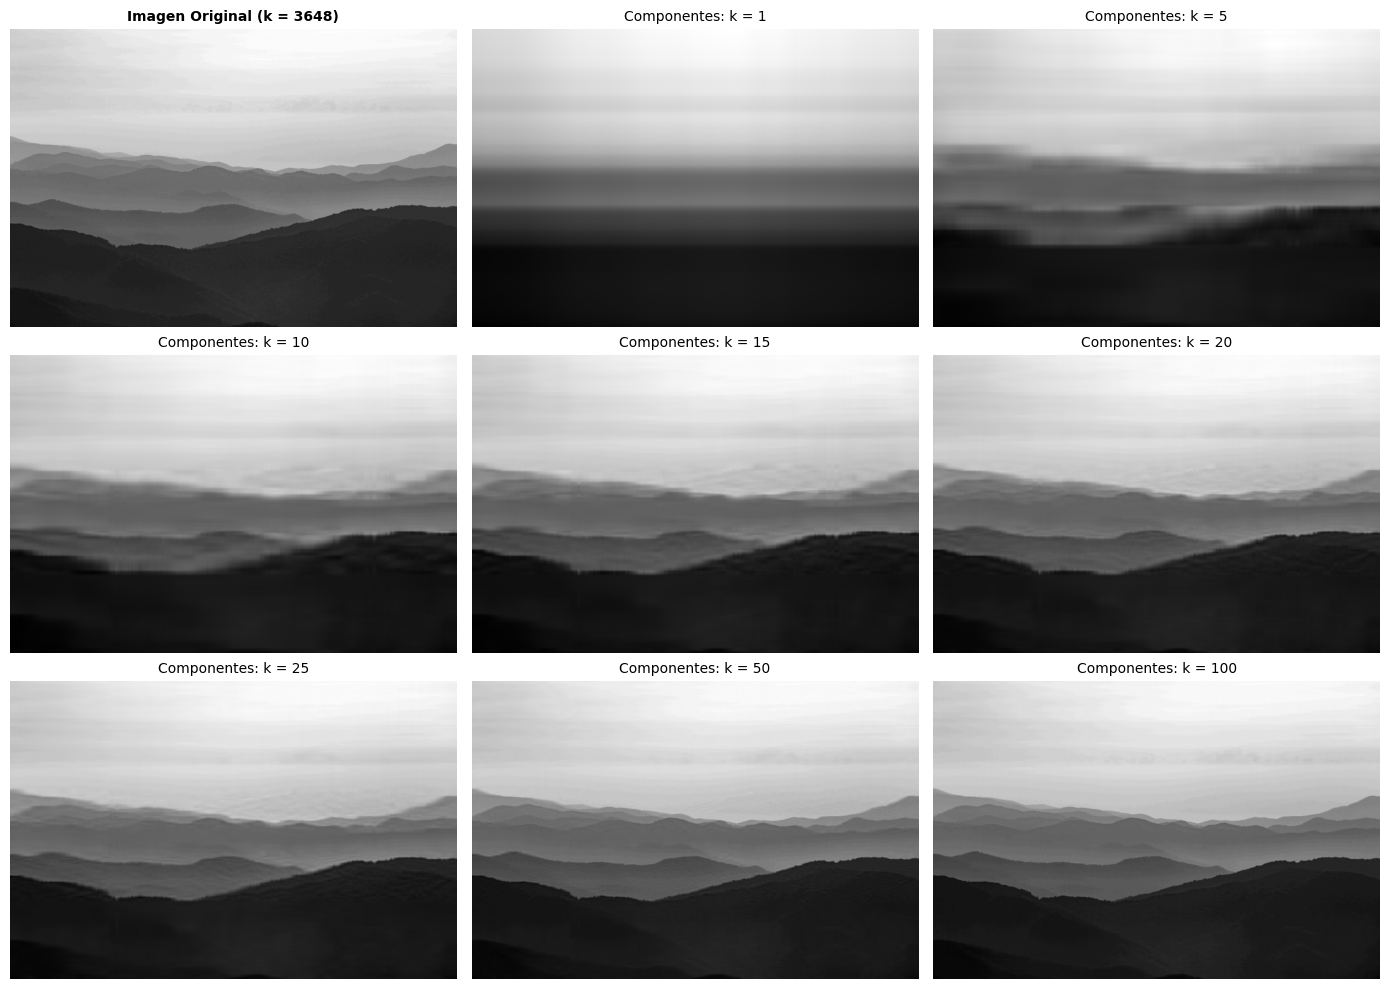

In [ ]:
# =====================================================================
# PLANTILLA 3: Compresión e Inspección de Imágenes Mediante SVD
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cbook import get_sample_data

# ---------------------------------------------------------------------
# PASO 1: Lectura de una imagen de ejemplo incluida con Matplotlib
# ---------------------------------------------------------------------
image_path = get_sample_data("grace_hopper.jpg", asfileobj=False)
img = plt.imread(image_path)

# Convertimos la imagen RGB a escala de grises con luminancia ponderada.
gray_image = img[..., :3] @ np.array([0.299, 0.587, 0.114])

# ---------------------------------------------------------------------
# PASO 2: Cómputo de la Descomposición SVD
# ---------------------------------------------------------------------
u, s, v = np.linalg.svd(gray_image, full_matrices=False)

print("--- DIMENSIONES DE LAS MATRICES OBTENIDAS ---")
print(f"Dimensión de U       : {u.shape}")
print(f"Vector s (Valores σ) : {s.shape}")
print(f"Dimensión de V^T     : {v.shape}\n")

# ---------------------------------------------------------------------
# PASO 3: Reconstrucción Progresiva con Diferentes Componentes (k)
# ---------------------------------------------------------------------
# Definimos el total disponible dinámicamente según la resolución real detectada
total_componentes = len(s)
comps = [total_componentes, 1, 5, 10, 15, 20, 25, 50, 100]

plt.figure(figsize=(14, 10))

for i, k in enumerate(comps):
    # Reconstrucción matemática restringida usando los primeros k elementos
    low_rank = u[:, :k] @ np.diag(s[:k]) @ v[:k, :]

    plt.subplot(3, 3, i + 1)
    plt.imshow(low_rank, cmap='gray')
    plt.axis('off')  # Remueve los ejes para una visualización limpia de la imagen

    if i == 0:
        plt.title(f"Imagen Original (k = {k})", fontsize=10, fontweight='bold')
    else:
        plt.title(f"Componentes: k = {k}", fontsize=10)

plt.tight_layout()
plt.show()